<a href="https://colab.research.google.com/github/vivekjain060305-coder/vivek_ML_Practicals/blob/main/ML_extra_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Vivek Jain
P10 Extra Spotify

CS23094

Aim: To perform Hierarchical Clustering using agglomerative methods and interpret dendrograms for cluster formation.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
path="/content/drive/MyDrive/ML_lab/Spotify_Songs_Dataset.csv"
df = pd.read_csv(path)
df.head()

/tmp/ipykernel_161/161653847.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73.0,230666.0,False,0.676,0.4610,...,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,149610.0,False,0.420,0.1660,...,-17.235,1.0,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4.0,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,210826.0,False,0.438,0.3590,...,-9.734,1.0,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4.0,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71.0,201933.0,False,0.266,0.0596,...,-18.515,1.0,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.0,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82.0,198853.0,False,0.618,0.4430,...,-9.681,1.0,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4.0,acoustic


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35782 entries, 0 to 35781
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        35782 non-null  int64  
 1   track_id          35782 non-null  object 
 2   artists           35781 non-null  object 
 3   album_name        35781 non-null  object 
 4   track_name        35781 non-null  object 
 5   popularity        35781 non-null  float64
 6   duration_ms       35781 non-null  float64
 7   explicit          35781 non-null  object 
 8   danceability      35781 non-null  float64
 9   energy            35781 non-null  float64
 10  key               35781 non-null  float64
 11  loudness          35781 non-null  float64
 12  mode              35781 non-null  float64
 13  speechiness       35781 non-null  float64
 14  acousticness      35781 non-null  float64
 15  instrumentalness  35781 non-null  float64
 16  liveness          35781 non-null  float6

In [7]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,35782.000000,35781.000000,3.578100e+04,35781.000000,35781.000000,35781.000000,35781.000000,35781.000000,35781.000000,35781.000000,35781.000000,35781.000000,35781.000000,35781.000000,35781.000000
mean,17890.500000,32.961041,2.322769e+05,0.579965,0.640952,5.325592,-8.368696,0.635086,0.095899,0.303176,0.192458,0.205067,0.463169,122.591508,3.910902
std,10329.518003,22.396057,1.264804e+05,0.171833,0.251164,3.564674,5.125260,0.481413,0.145261,0.333524,0.333409,0.183434,0.260297,29.043655,0.409500
min,0.000000,0.000000,1.745300e+04,0.000000,0.000020,0.000000,-41.808000,0.000000,0.000000,0.000000,0.000000,0.011200,0.000000,0.000000,0.000000
25%,8945.250000,16.000000,1.735600e+05,0.470000,0.476000,2.000000,-10.145000,0.000000,0.036100,0.013100,0.000000,0.095800,0.243000,100.548000,4.000000
50%,17890.500000,34.000000,2.134070e+05,0.594000,0.688000,5.000000,-7.049000,1.000000,0.049000,0.145000,0.000151,0.127000,0.446000,122.975000,4.000000
75%,26835.750000,50.000000,2.650900e+05,0.707000,0.849000,8.000000,-5.065000,1.000000,0.084500,0.580000,0.218000,0.258000,0.671000,139.981000,4.000000
max,35781.000000,100.000000,4.789026e+06,0.983000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,0.995000,0.995000,0.995000,243.372000,5.000000


In [8]:
df.shape
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [9]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,1
duration_ms,1
explicit,1
danceability,1
energy,1


In [10]:
df = df.dropna()

In [11]:
df = df.drop(['track_id','track_name','artist_name'], axis=1, errors='ignore')

In [12]:
df = df.select_dtypes(include=['int64','float64'])

In [13]:
df = df.sample(n=500, random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

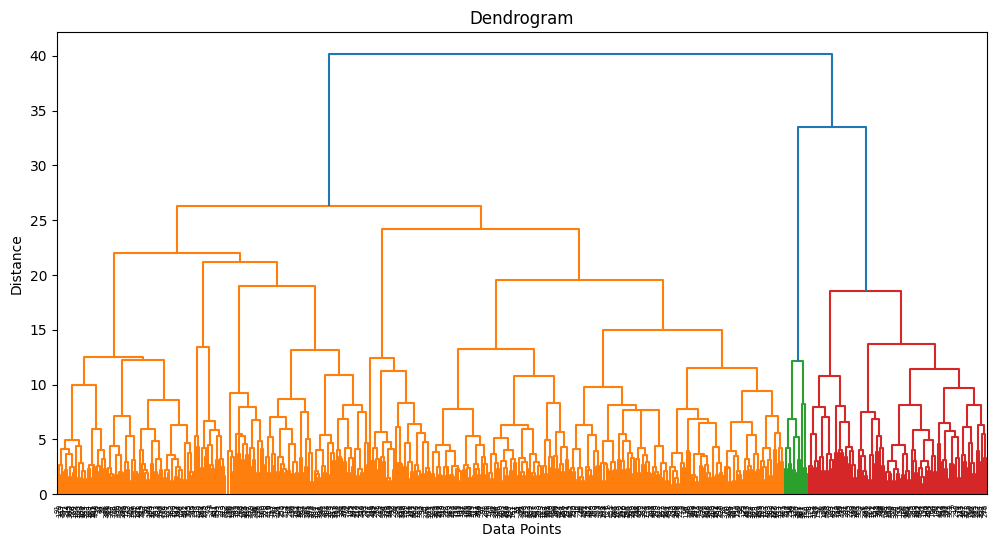

In [15]:
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(12,6))
sch.dendrogram(sch.linkage(scaled_data, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [16]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
y_pred = hc.fit_predict(scaled_data)
print(y_pred)

[0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 2 0 1 0 0 0 1 0 1 0 0 1 1 0 0 1 0 1 0
 0 0 2 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0
 1 1 1 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2
 1 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
 1 0 0 0 0 0 1 1 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 1
 0 1 0 0 0 0 0 1 0 0 0 0 1 2 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 2 0 1 0 0 1 2
 0 0 0 0 0 1 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1
 0 1 0 0 1 0 1 0 1 0 2 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 2 1 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 2 1 0 1 1 1 2 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 2 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 1
 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 1 0 0 0 0 0 0 1 

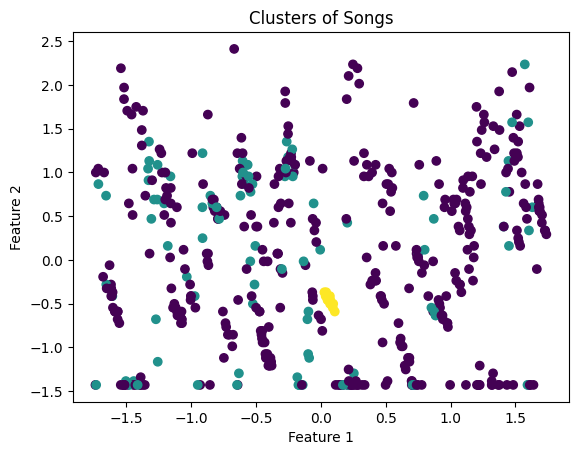

In [17]:
plt.scatter(scaled_data[:,0], scaled_data[:,1], c=y_pred)
plt.title("Clusters of Songs")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()